In [20]:
import pandas as pd

url = "https://sundowner.colorado.edu/weather/atoc1/wxobs20051004.txt"

df = pd.read_fwf(url, header=[0, 1], skiprows=[2])

date_col = [c for c in df.columns if c[1] == "Date"][0]
time_col = [c for c in df.columns if c[1] == "Time"][0]

t = (
    df[time_col]
    .astype(str)
    .str.strip()
    .str.replace(r"a$", "AM", regex=True)
    .str.replace(r"p$", "PM", regex=True)
)

dt = pd.to_datetime(
    df[date_col].astype(str).str.strip() + " " + t,
    format="%m/%d/%y %I:%M%p",
    errors="coerce",
)

df = df.set_index(dt).drop(columns=[date_col, time_col])
df.index.name = "datetime"

df.columns = [
    "_".join([str(a).strip(), str(b).strip()]).replace(" ", "_").strip("_")
    for a, b in df.columns
]

df

,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt.,Wind_Speed,Wind_Dir,Wind_Run,Hi_Speed,Hi_Dir,...,Solar_Rad..1,Heat_D-D,Cool_D-D,In_Temp,In_Hum,Unnamed:_27_level_0_ET,Wind_Samp,Wind_Tx,ISS_Recept,Arc._Int.
datetime,,,,,,,,,,,,,,,,,,,,,
2005-10-03 00:05:00,67.8,68.6,67.8,26,31.6,2.0,N,0.17,5.0,NNE,...,0,0.000,0.010,67.2,24,0.0,110,1,96.5,5
2005-10-03 00:10:00,65.5,67.8,65.5,30,33.2,3.0,NNE,0.25,11.0,ENE,...,0,0.000,0.002,67.2,23,0.0,107,1,93.9,5
2005-10-03 00:15:00,63.4,65.3,63.4,33,33.8,3.0,NNW,0.25,9.0,N,...,0,0.006,0.000,67.2,24,0.0,113,1,99.1,5
2005-10-03 00:20:00,62.3,63.2,62.3,35,34.3,1.0,NNE,0.08,7.0,N,...,0,0.009,0.000,67.2,24,0.0,110,1,96.5,5
2005-10-03 00:25:00,61.8,62.3,61.8,37,35.2,0.0,ENE,0.00,2.0,ENE,...,0,0.011,0.000,67.2,25,0.0,109,1,95.6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-10-04 23:35:00,49.9,49.9,49.5,44,28.8,6.0,WNW,0.50,15.0,SW,...,0,0.052,0.000,69.2,21,0.0,108,1,94.7,5
2005-10-04 23:40:00,49.8,49.9,49.8,44,28.7,4.0,SW,0.33,15.0,WNW,...,0,0.053,0.000,69.2,20,0.0,110,1,96.5,5
2005-10-04 23:45:00,50.1,50.1,49.8,41,27.3,7.0,WNW,0.58,14.0,WNW,...,0,0.052,0.000,69.4,20,0.0,106,1,93.0,5


In [21]:
#accessing the columns I want to make a plot with
print(df['Wind_Speed'])
print(df['Wind_Dir'])

datetime
2005-10-03 00:05:00    2.0
2005-10-03 00:10:00    3.0
2005-10-03 00:15:00    3.0
2005-10-03 00:20:00    1.0
2005-10-03 00:25:00    0.0
                      ... 
2005-10-04 23:35:00    6.0
2005-10-04 23:40:00    4.0
2005-10-04 23:45:00    7.0
2005-10-04 23:50:00    5.0
2005-10-04 23:55:00    7.0
Name: Wind_Speed, Length: 575, dtype: float64
datetime
2005-10-03 00:05:00      N
2005-10-03 00:10:00    NNE
2005-10-03 00:15:00    NNW
2005-10-03 00:20:00    NNE
2005-10-03 00:25:00    ENE
                      ... 
2005-10-04 23:35:00    WNW
2005-10-04 23:40:00     SW
2005-10-04 23:45:00    WNW
2005-10-04 23:50:00    WNW
2005-10-04 23:55:00      W
Name: Wind_Dir, Length: 575, dtype: object


In [22]:
#converting cardinal direction to degrees so it can be plotted
compass_to_deg = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

df['Wind_Dir_deg'] = df['Wind_Dir'].map(compass_to_deg)

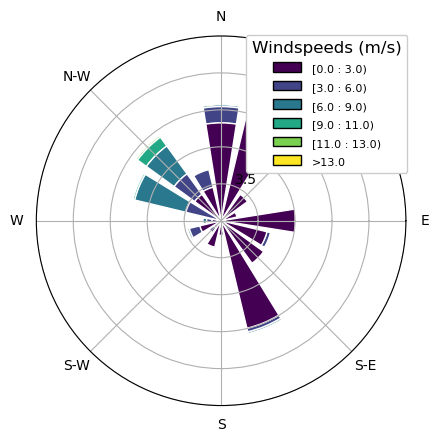

In [23]:
# making a windrose graph! (I learned about this graph in another class
import matplotlib.pyplot as plt
from windrose import WindroseAxes

fig = plt.figure()
ax = plt.subplot(1,1,1, projection="windrose")
ax.bar(df['Wind_Dir_deg'], df['Wind_Speed'], normed=True, edgecolor='white', bins=[0,3,6,9,11,13])
ax.set_legend(title='Windspeeds (m/s)', title_fontsize=12, framealpha=1, loc='upper right')
plt.show()